<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FDenseNet-model/densenet_base_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
TRAIN_DIR = "/content/drive/MyDrive/dataset/Train"
VAL_DIR   = "/content/drive/MyDrive/dataset/Validation"
TEST_DIR  = "/content/drive/MyDrive/dataset/Test"

In [3]:
import os

print("Train:", os.listdir(TRAIN_DIR))
print("Validation:", os.listdir(VAL_DIR))
print("Test:", os.listdir(TEST_DIR))

Train: ['Tinea', 'Leishmaniasis', 'Eczema']
Validation: ['Tinea', 'Eczema', 'Leishmaniasis']
Test: ['Leishmaniasis', 'Eczema', 'Tinea']


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

Found 2688 files belonging to 3 classes.


In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 574 files belonging to 3 classes.


In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 573 files belonging to 3 classes.


In [9]:
class_names = train_ds.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Eczema', 'Leishmaniasis', 'Tinea']
Number of classes: 3


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [12]:
num_classes = len(class_names)

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),

    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,675 (27.85 MB)

 Trainable params: 263,171 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [16]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 701s 8s/step - accuracy: 0.5789 - loss: 2.0256 - val_accuracy: 0.7909 - val_loss: 0.7654 - learning_rate: 1.0000e-04
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 723s 8s/step - accuracy: 0.7188 - loss: 0.9925 - val_accuracy: 0.8136 - val_loss: 0.6052 - learning_rate: 1.0000e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 665s 8s/step - accuracy: 0.7779 - loss: 0.6467 - val_accuracy: 0.8258 - val_loss: 0.5542 - learning_rate: 1.0000e-04
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 690s 8s/step - accuracy: 0.8017 - loss: 0.5490 - val_accuracy: 0.8362 - val_loss: 0.4933 - learning_rate: 1.0000e-04
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 686s 8s/step - accuracy: 0.8344 - loss: 0.4678 - val_accuracy: 0.8258 - val_loss: 0.4797 - learning_rate: 1.0000e-04
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 658s 8s/step - accuracy: 0.8534 - loss: 0.3918 - val_accuracy: 0.8484 - val_loss: 0.4531 - learning_rate: 1.0000e-04
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 652s 8s/step - accuracy: 0.8653 

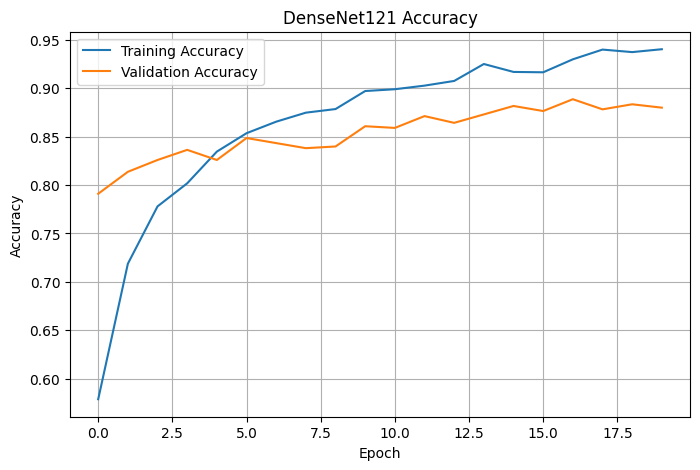

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("DenseNet121 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

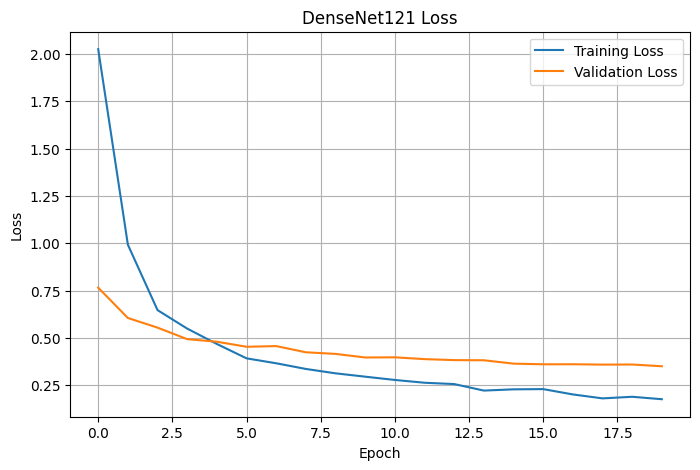

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("DenseNet121 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [19]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 131s 7s/step - accuracy: 0.9110 - loss: 0.2615
Test Loss: 0.2615147531032562
Test Accuracy: 0.9109947681427002


In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

In [21]:
cm = confusion_matrix(y_true, y_pred)

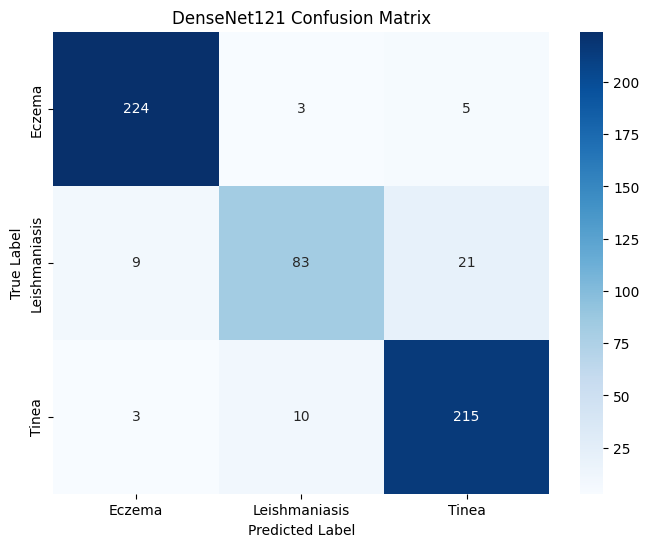

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet121 Confusion Matrix")

plt.show()

In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

       Eczema       0.95      0.97      0.96       232
Leishmaniasis       0.86      0.73      0.79       113
        Tinea       0.89      0.94      0.92       228

     accuracy                           0.91       573
    macro avg       0.90      0.88      0.89       573
 weighted avg       0.91      0.91      0.91       573



In [24]:
MODEL_PATH = "/content/drive/MyDrive/dataset/DenseNet121_Tinea_base_Model.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!
